In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt



In [ ]:
for i in [1,2,3,4]:
    gf_dir = f'{large_data_dir}/FFPE_decrosslink_additional_patients/BC' + str(i) + '_giftwrap/'
    adata_path = f'{large_data_dir}/FFPE_decrosslink_additional_patients/BC00{i}_sample_filtered_feature_bc_matrix.h5'

    manifest = pd.read_csv('../../3_figure_FFPE/data/glioma_manifest.tsv',sep='\t',index_col=0)
    manifest = manifest.loc[manifest['name'] != 'ATRX 0bp_0'] ### exclude because it is missing for both BC2 libraries, suggesting opool issue

    probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold = 50, min_percent_supporting = -1, adata_path = adata_path, collapse_across_probes=True)
    probe_reads = probe_reads.merge(manifest[['name','gene','gapfill_from_transcriptome','gap_probe_sequence']], left_on = 'probe_idx', right_index=True)

    adata = sc.read_10x_h5(adata_path)

    probe_counts_per_cell = (probe_reads['name'].value_counts() / adata.n_obs).reindex(manifest['name']).fillna(0)
    probe_counts_per_cell.name = 'BC' + str(i)

    if i == 1:
        probe_counts_df = probe_counts_per_cell.to_frame()
    else:
        probe_counts_df = probe_counts_df.join(probe_counts_per_cell.to_frame())


35149 UMIs found
Collapsing UMIs across probes, 35149 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (50) and min percent supporting (-1), 25640 UMIs remaining (72.95%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 25640 UMIs remaining (72.95%)
43204 UMIs found
Collapsing UMIs across probes, 43204 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (50) and min percent supporting (-1), 32565 UMIs remaining (75.37%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 32565 UMIs remaining (75.37%)
332685 UMIs found
Collapsing UMIs across probes, 332685 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (50) and min percent supporting (-1), 236303 UMIs remaining (71.03%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 236303 UMI

/tmp/ipykernel_2100482/3139656674.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


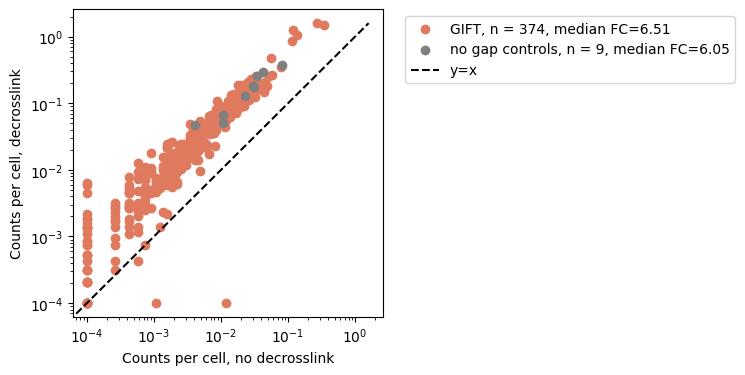

In [3]:
dcl_BC = 'BC3'
no_dcl_BC = 'BC1'

fig,ax = plt.subplots(figsize=(4,4))

median_FC = (probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),dcl_BC] / probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),no_dcl_BC]).median()
ax.scatter(probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),no_dcl_BC] + 0.0001, probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),dcl_BC] + 0.0001, color = '#E07A5F', label='GIFT, n = ' + str(probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),no_dcl_BC].count()) + ', median FC=' + str(round(median_FC,2)))

median_FC = (probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),dcl_BC] / probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),no_dcl_BC]).median()
ax.scatter(probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),no_dcl_BC] + 0.0001, probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),dcl_BC] + 0.0001, color = 'grey', label='no gap controls, n = ' + str(probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),no_dcl_BC].count()) + ', median FC=' + str(round(median_FC,2)))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot([probe_counts_df.min().min(), probe_counts_df.max().max()], 
    [probe_counts_df.min().min(), probe_counts_df.max().max()], 
    'k--', alpha=1, label='y=x')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Counts per cell, no decrosslink')
ax.set_ylabel('Counts per cell, decrosslink')

plt.tight_layout()

plt.savefig('../plots/gapfill_counts_dcl_comparison_patient_' + dcl_BC + '_vs_' + no_dcl_BC + '.pdf')

/tmp/ipykernel_2100482/248689101.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


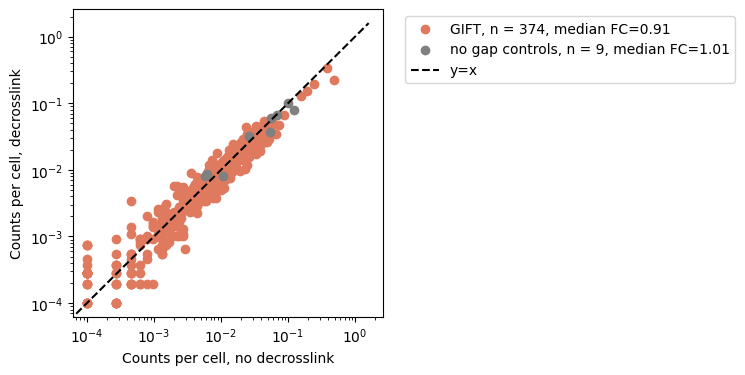

In [4]:
dcl_BC = 'BC4'
no_dcl_BC = 'BC2'

fig,ax = plt.subplots(figsize=(4,4))

median_FC = (probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),dcl_BC] / probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),no_dcl_BC]).median()
ax.scatter(probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),no_dcl_BC] + 0.0001, probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),dcl_BC] + 0.0001, color = '#E07A5F', label='GIFT, n = ' + str(probe_counts_df.loc[~probe_counts_df.index.str.contains('0bp'),no_dcl_BC].count()) + ', median FC=' + str(round(median_FC,2)))

median_FC = (probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),dcl_BC] / probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),no_dcl_BC]).median()
ax.scatter(probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),no_dcl_BC] + 0.0001, probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),dcl_BC] + 0.0001, color = 'grey', label='no gap controls, n = ' + str(probe_counts_df.loc[probe_counts_df.index.str.contains('0bp'),no_dcl_BC].count()) + ', median FC=' + str(round(median_FC,2)))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot([probe_counts_df.min().min(), probe_counts_df.max().max()], 
    [probe_counts_df.min().min(), probe_counts_df.max().max()], 
    'k--', alpha=1, label='y=x')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Counts per cell, no decrosslink')
ax.set_ylabel('Counts per cell, decrosslink')

plt.tight_layout()

plt.savefig('../plots/gapfill_counts_dcl_comparison_patient_' + dcl_BC + '_vs_' + no_dcl_BC + '.pdf')